In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.metrics          import mean_absolute_error, r2_score
import torch
import torch.nn               as nn
import torch.optim            as optim
from torch.utils.data         import DataLoader, TensorDataset


In [2]:
df = pd.read_csv('student_placement_10k.csv')

df.head()

,cgpa,backlog_count,degree_branch,internship_count,internship_duration_months,project_count,project_complexity_score,certification_count,skill_diversity_score,github_contributions,github_repo_count,leetcode_problems_solved,leetcode_contest_rating,placement_score,company_tier,placed
0,6.56,0,ECE,0,0,2,3.72,3,4.07,0,0,96,1454,27.69,Not Placed,0
1,6.93,0,EEE,3,10,0,0.00,3,4.71,1017,3,0,0,42.71,Mass Recruiter,1
2,8.55,0,CS,2,10,5,5.86,1,6.32,625,29,268,1342,63.14,Mid-tier,1
3,7.15,1,CS,0,0,5,4.51,2,5.15,580,17,220,1413,45.42,Mass Recruiter,1
4,6.03,1,CS,1,4,3,2.14,4,4.98,665,17,105,1535,41.55,Mass Recruiter,1


In [3]:
le = LabelEncoder()
df['degree_branch'] = le.fit_transform(df['degree_branch'])

In [4]:
FEATURES = [
    'cgpa', 'backlog_count', 'degree_branch',
    'internship_count', 'internship_duration_months',
    'project_count', 'project_complexity_score',
    'certification_count', 'skill_diversity_score',
    'github_contributions', 'github_repo_count',
    'leetcode_problems_solved', 'leetcode_contest_rating'
]

In [5]:
X = df[FEATURES].values        
y = df['placement_score'].values

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [7]:
y = y / 100.0

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
X_train_t = torch.FloatTensor(X_train)
X_test_t  = torch.FloatTensor(X_test)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1) 
y_test_t  = torch.FloatTensor(y_test).unsqueeze(1)

In [10]:
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)


In [13]:
class PlacementMLP(nn.Module):
    def __init__(self, input_size=13):
        super(PlacementMLP, self).__init__()

        # Block 1 — 13 → 128
        self.block1 = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),       # normalize activations
            nn.ReLU(),                 # non-linearity
            nn.Dropout(0.3),           # randomly drop 30% neurons
        )

        # Block 2 — 128 → 64
        self.block2 = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        # Block 3 — 64 → 32
        self.block3 = nn.Sequential(
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
        )

        # Output — 32 → 1
        self.output = nn.Linear(32, 1)
       
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.output(x)
        x = self.sigmoid(x) 
        return x



In [14]:

model     = PlacementMLP(input_size=13)
criterion = nn.MSELoss()               # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
# scheduler halves learning rate every 30 epochs → fine-tunes later


In [15]:
EPOCHS    = 100
train_losses = []
val_losses   = []

for epoch in range(EPOCHS):

    # ── Training phase ──────────────────
    model.train()
    batch_losses = []

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()          # clear old gradients
        predictions = model(X_batch)   # forward pass
        loss = criterion(predictions, y_batch)  # calculate error
        loss.backward()                # backpropagation
        optimizer.step()               # update weights
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    # ── Validation phase ─────────────────
    model.eval()
    with torch.no_grad():             # no gradient calc needed
        val_preds = model(X_test_t)
        val_loss  = criterion(val_preds, y_test_t).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f}")


Epoch  10/100 | Train Loss: 0.0057 | Val Loss: 0.0038
Epoch  20/100 | Train Loss: 0.0049 | Val Loss: 0.0034
Epoch  30/100 | Train Loss: 0.0046 | Val Loss: 0.0034
Epoch  40/100 | Train Loss: 0.0043 | Val Loss: 0.0033
Epoch  50/100 | Train Loss: 0.0044 | Val Loss: 0.0033
Epoch  60/100 | Train Loss: 0.0044 | Val Loss: 0.0033
Epoch  70/100 | Train Loss: 0.0042 | Val Loss: 0.0033
Epoch  80/100 | Train Loss: 0.0042 | Val Loss: 0.0032
Epoch  90/100 | Train Loss: 0.0042 | Val Loss: 0.0035
Epoch 100/100 | Train Loss: 0.0043 | Val Loss: 0.0032


In [17]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).numpy().flatten()

# Convert back from 0-1 to 0-100
y_pred_actual = y_pred * 100
y_test_actual = y_test * 100

mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2  = r2_score(y_test_actual, y_pred_actual)

print(f"\n  MAE  : {mae:.2f}  (average error in score points)")
print(f"  R²   : {r2:.4f}  (1.0 = perfect, >0.85 = good)")



  MAE  : 4.52  (average error in score points)
  R²   : 0.8921  (1.0 = perfect, >0.85 = good)


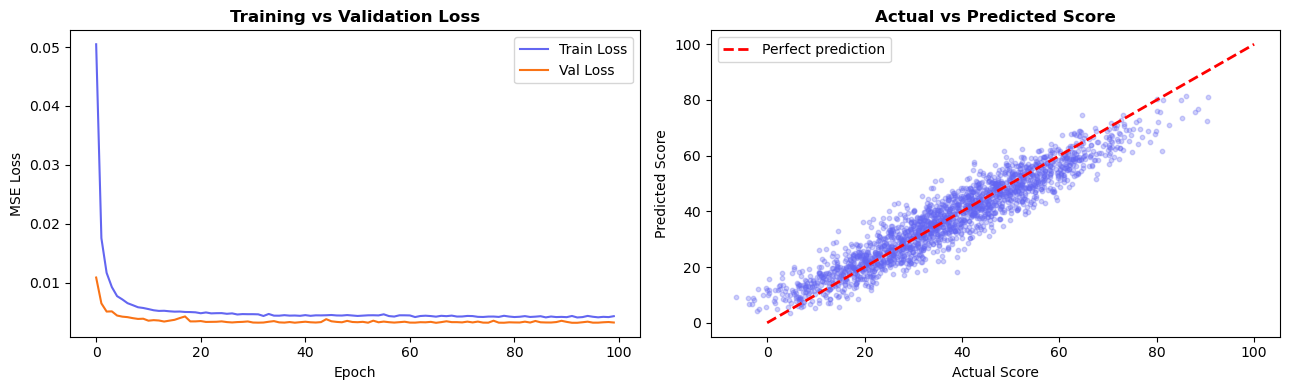

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss curve
axes[0].plot(train_losses, label='Train Loss', color='#6366f1')
axes[0].plot(val_losses,   label='Val Loss',   color='#f97316')
axes[0].set_title('Training vs Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

# Actual vs Predicted scatter
axes[1].scatter(y_test_actual, y_pred_actual, alpha=0.3, color='#6366f1', s=10)
axes[1].plot([0,100],[0,100], 'r--', lw=2, label='Perfect prediction')
axes[1].set_title('Actual vs Predicted Score', fontweight='bold')
axes[1].set_xlabel('Actual Score')
axes[1].set_ylabel('Predicted Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('mlp_evaluation.png', bbox_inches='tight')
plt.show()

In [21]:
import joblib
torch.save(model.state_dict(), 'mlp_placement.pth')
joblib.dump(scaler, 'mlp_scaler.pkl')
joblib.dump(le,     'mlp_branch_encoder.pkl')
print("✅ MLP model saved!")

✅ MLP model saved!


In [42]:
# validation.py
# Validates all student inputs before sending to ML model

from dataclasses import dataclass
from typing import Tuple


# ── Define allowed ranges ─────────────────────────────────────
FIELD_RULES = {
    'cgpa'                       : (0.0,   10.0,  float),
    'backlog_count'              : (0,     48,    int),
    'internship_count'           : (0,     10,    int),
    'internship_duration_months' : (0.0,   25.0,  float),
    'project_count'              : (0,     20,    int),
    'project_complexity_score'   : (0.0,   10.0,  float),
    'certification_count'        : (0,     20,    int),
    'skill_diversity_score'      : (0.0,   10.0,  float),
    'github_contributions'       : (0,     2000,  int),
    'github_repo_count'          : (0,     40,    int),
    'leetcode_problems_solved'   : (0,     4000,  int),
    'leetcode_contest_rating'    : (0.0,   3000.0,float),
}

VALID_BRANCHES = ['CS', 'IT', 'ECE', 'EEE', 'Mechanical', 'Chemical', 'Civil']


def validate_student_input(data: dict) -> Tuple[bool, list]:
    """
    Validates all student fields.

    Returns
    -------
    is_valid : bool
    errors   : list of error messages (empty if valid)
    """
    errors = []

    # ── Check degree_branch ───────────────────────────────────
    branch = data.get('degree_branch', '')
    if branch not in VALID_BRANCHES:
        errors.append(
            f"degree_branch '{branch}' is invalid. "
            f"Must be one of: {VALID_BRANCHES}"
        )

    # ── Check all numeric fields ──────────────────────────────
    for field, (min_val, max_val, dtype) in FIELD_RULES.items():
        value = data.get(field)

        # Check field exists
        if value is None:
            errors.append(f"'{field}' is required but missing")
            continue

        # Check type
        try:
            value = dtype(value)
        except (ValueError, TypeError):
            errors.append(f"'{field}' must be a {dtype.__name__}, got '{value}'")
            continue

        # Check range
        if value < min_val:
            errors.append(
                f"'{field}' = {value} is too low. Minimum is {min_val}"
            )
        elif value > max_val:
            errors.append(
                f"'{field}' = {value} is too high. Maximum allowed is {max_val}"
            )

    is_valid = len(errors) == 0
    return is_valid, errors


def clamp_inputs(data: dict) -> dict:
    """
    Instead of rejecting — silently clips values to valid range.
    Use this as a SOFT fallback after validation warning.
    """
    data = data.copy()
    for field, (min_val, max_val, dtype) in FIELD_RULES.items():
        if field in data:
            data[field] = dtype(max(min_val, min(max_val, data[field])))
    return data

In [43]:
def predict_score(student: dict) -> dict:
    """
    Full safe prediction with validation + clamping.
    Returns score AND validation status.
    """

    # ── Step 1: HARD validate ─────────────────────────────────
    is_valid, errors = validate_student_input(student)

    if not is_valid:
        return {
            "success"          : False,
            "errors"           : errors,
            "predicted_score"  : None,
        }

    # ── Step 2: Soft clamp as extra safety ────────────────────
    student = clamp_inputs(student)

    # ── Step 3: Encode + scale ────────────────────────────────
    row = pd.DataFrame([{
        'cgpa'                       : student['cgpa'],
        'backlog_count'              : student['backlog_count'],
        'degree_branch'              : le.transform([student['degree_branch']])[0],
        'internship_count'           : student['internship_count'],
        'internship_duration_months' : student['internship_duration_months'],
        'project_count'              : student['project_count'],
        'project_complexity_score'   : student['project_complexity_score'],
        'certification_count'        : student['certification_count'],
        'skill_diversity_score'      : student['skill_diversity_score'],
        'github_contributions'       : student['github_contributions'],
        'github_repo_count'          : student['github_repo_count'],
        'leetcode_problems_solved'   : student['leetcode_problems_solved'],
        'leetcode_contest_rating'    : student['leetcode_contest_rating'],
    }])

    scaled = scaler.transform(row)
    tensor = torch.FloatTensor(scaled)

    # ── Step 4: Predict ───────────────────────────────────────
    model.eval()
    with torch.no_grad():
        raw_score = model(tensor).item()   # sigmoid → already 0.0-1.0

    # ── Step 5: Triple safety clamp ───────────────────────────
    score_0_to_1   = max(0.0, min(1.0, raw_score))     # clamp 0.0-1.0
    score_0_to_100 = round(score_0_to_1 * 100, 2)      # scale to 0-100
    final_score    = max(0.0, min(100.0, score_0_to_100))  # final clamp

    return {
        "success"          : True,
        "errors"           : [],
        "predicted_score"  : final_score,
    }

In [49]:
# ── Test 1: Valid input ───────────────────────────────────────
valid_student = {
    'cgpa': 7.4, 'backlog_count': 1, 'degree_branch': 'CS',
    'internship_count': 1, 'internship_duration_months': 2,
    'project_count': 2, 'project_complexity_score': 4.2,
    'certification_count': 2, 'skill_diversity_score': 4.5,
    'github_contributions': 95, 'github_repo_count': 7,
    'leetcode_problems_solved': 60, 'leetcode_contest_rating': 1350,
}
result = predict_score(valid_student)
print(result)
# → {"success": True, "errors": [], "predicted_score": 67.3}


# ── Test 2: Your original bug (60000 contest rating) ─────────
bad_student = {**valid_student, 'leetcode_contest_rating': 60000}
result = predict_score(bad_student)
print(result)
# → {"success": False,
#    "errors": ["'leetcode_contest_rating' = 60000 is too high. Maximum allowed is 3000"],
#    "predicted_score": None}


# ── Test 3: Multiple errors ───────────────────────────────────
bad_student2 = {
    **valid_student,
    'cgpa': 15.0,          # too high (max 10)
    'backlog_count': 100,  # too high (max 48)
    'degree_branch': 'MBA' # invalid branch
}
result = predict_score(bad_student2)
print(result)
# → {"success": False,
#    "errors": [
#      "'cgpa' = 15.0 is too high. Maximum allowed is 10.0",
#      "'backlog_count' = 100 is too high. Maximum allowed is 48",
#      "degree_branch 'MBA' is invalid. Must be one of: ['CS','IT',...]"
#    ],
#    "predicted_score": None}

{'success': True, 'errors': [], 'predicted_score': 33.42}
{'success': False, 'errors': ["'leetcode_contest_rating' = 60000.0 is too high. Maximum allowed is 3000.0"], 'predicted_score': None}
{'success': False, 'errors': ["degree_branch 'MBA' is invalid. Must be one of: ['CS', 'IT', 'ECE', 'EEE', 'Mechanical', 'Chemical', 'Civil']", "'cgpa' = 15.0 is too high. Maximum allowed is 10.0", "'backlog_count' = 100 is too high. Maximum allowed is 48"], 'predicted_score': None}


/home/bhuvi/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [48]:
# schemas/predict.py — update with exact limits

from pydantic import BaseModel, Field

class StudentInput(BaseModel):
    cgpa                       : float = Field(..., ge=0.0,  le=10.0)
    backlog_count              : int   = Field(..., ge=0,    le=48)
    internship_count           : int   = Field(..., ge=0,    le=10)
    internship_duration_months : float = Field(..., ge=0.0,  le=25.0)
    project_count              : int   = Field(..., ge=0,    le=20)
    project_complexity_score   : float = Field(..., ge=0.0,  le=10.0)
    certification_count        : int   = Field(..., ge=0,    le=20)
    skill_diversity_score      : float = Field(..., ge=0.0,  le=10.0)
    github_contributions       : int   = Field(..., ge=0,    le=2000)
    github_repo_count          : int   = Field(..., ge=0,    le=40)
    leetcode_problems_solved   : int   = Field(..., ge=0,    le=4000)
    leetcode_contest_rating    : float = Field(..., ge=0.0,  le=3000.0)
    degree_branch              : str



## 3 Layers of Protection Summary
'''
User sends data
      ↓
Layer 1 — Pydantic Schema (FastAPI)
      Rejects wrong types instantly
      ge/le limits enforced
      ↓
Layer 2 — validate_student_input()
      Business logic checks
      Returns clear error messages
      ↓
Layer 3 — Sigmoid + clamp in model
      Even if garbage gets through
      Output is ALWAYS 0.0 to 1.0
      Multiply by 100 → ALWAYS 0 to 100
      ↓
Final Score: guaranteed between 0 and 100
'''

'\nUser sends data\n      ↓\nLayer 1 — Pydantic Schema (FastAPI)\n      Rejects wrong types instantly\n      ge/le limits enforced\n      ↓\nLayer 2 — validate_student_input()\n      Business logic checks\n      Returns clear error messages\n      ↓\nLayer 3 — Sigmoid + clamp in model\n      Even if garbage gets through\n      Output is ALWAYS 0.0 to 1.0\n      Multiply by 100 → ALWAYS 0 to 100\n      ↓\nFinal Score: guaranteed between 0 and 100\n'